## Import Libraries

In [1]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

## Scrape BCIT Entrance Page
### I will be using a BCIT BITMAN url to retrieve information for the map.

In [2]:
url = 'https://www.bcit.ca/programs/business-information-technology-management-diploma-full-time-6235dipma/#entry'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

print(f"Fetching: {url}")
try:
    resp = requests.get(url, headers=headers, timeout=20)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.content, 'html.parser')
    
    entry_anchor = soup.find('a', {'name': 'entry'}) or soup.find(id='entry')
    if entry_anchor:
        section = entry_anchor.find_parent(['section', 'div', 'article']) or entry_anchor.parent
        raw_text = section.get_text(separator=' ', strip=True)
    else:
        raw_text = soup.get_text()
    
    print(f"Scraped {len(raw_text)} chars")
    print("Preview:", raw_text[:400], "...")
    
except Exception as e:
    print(f"Network error: {e}")
    raw_text = """
    Entrance requirements. Academics English Studies 12 (73%) or Communications 12 (73%). 
    Pre-calculus 12 (67%). Applicants transcripts reviewed. Competitive GPA entry. 
    Laptop Windows 10+ required. Check my.bcit.ca availability.
    """


Fetching: https://www.bcit.ca/programs/business-information-technology-management-diploma-full-time-6235dipma/#entry
Scraped 38642 chars
Preview: Overview The Business Information Technology Management Diploma provides foundational skills in information systems, economics, marketing, and leadership in the first year. In the second year, you can specialize in one of three options - Analytics Data, Artificial Intelligence, Enterprise Systems. Apply today for a rewarding career path. Delivery: in person. See details . If you’re looking to gain ...


## Advanced Text Parsing
### After scraping the information, I will sort through it to keep the useful data and remove the messy data.

In [3]:
patterns = {
    'english': r'(English\s*(?:Studies|Communications)?\s*12[^;.]*?[\d%]+)',
    'math': r'(Pre-calculus\s*12[^;.]*?[\d%]+)',
    'gpa': r'(GPA|grade\s+point|competitive[^;.]*?[\d.]+?)',
    'docs': r'(transcript|resume|application[^;.]*?)',
    'tech': r'(laptop|computer|Windows[^;.]*?)',
    'process': r'(interview|selection|review[^;.]*?)'
}

parsed_reqs = {}
for key, pattern in patterns.items():
    matches = re.findall(pattern, raw_text, re.I | re.DOTALL)
    parsed_reqs[key.title()] = [m.strip() for m in matches if m.strip()]

print("Parsed Requirements:")
for k, v in parsed_reqs.items():
    print(f"  {k}: {v}")


Parsed Requirements:
  English: ['English Studies 12 (67%']
  Math: []
  Gpa: ['competitive entry, using the first year GPA as the deciding factor.', 'competitive entry, using the first year GPA as the deciding factor.', 'Competitive entry : if the number of applicants exceeds available seats, BCIT will accept those deemed to have the best opportunity for success.', 'competitive application, it is recommended that you take no more than two courses per term ahead of time.', 'competitive by cumulative first-year GPA.', 'competitive advantage in the marketplace.', 'competitive advantage.']
  Docs: ['application', 'Application', 'Application', 'Application', 'transcript', 'application', 'transcript', 'application', 'application', 'application', 'application', 'application', 'application', 'Application', 'application', 'application', 'application', 'application', 'application', 'Application', 'application', 'application', 'Application', 'application', 'resume', 'application', 'application',

## Create & Export DataFrame

In [4]:
df_reqs = pd.DataFrame([
    {'Category': k, 'Details': '; '.join(v[:2]), 'Count': len(v)}  # Top 2 matches
    for k, v in parsed_reqs.items()
])
print("\n Requirements Table:")
print(df_reqs)

df_reqs.to_csv('bitman_entrance_detailed.csv', index=False)
df_reqs.to_excel('bitman_entrance.xlsx', index=False)
df_reqs.to_json('bitman_entrance.json', orient='records')
print("\n Exported: CSV, Excel, JSON")


 Requirements Table:
  Category                                            Details  Count
0  English                            English Studies 12 (67%      1
1     Math                                                         0
2      Gpa  competitive entry, using the first year GPA as...      7
3     Docs                           application; Application     37
4     Tech                                    laptop; Windows      7
5  Process                                  selection; review      9

 Exported: CSV, Excel, JSON


## Build Entrance Flow Graph
### Now I will start to construct the map

In [5]:
G = nx.DiGraph()

flow_steps = [
    ('START: Apply Online', 'English 12 (73%)'),
    ('English 12 (73%)', 'Pre-Calculus 12 (67%)'),
    ('Pre-Calculus 12 (67%)', 'Submit Transcripts'),
    ('Submit Transcripts', 'GPA Review'),
    ('GPA Review', 'ACCEPTED: Seat Reserved'),
    ('GPA Review', 'WAITLIST'),
    ('WAITLIST', 'CONDITIONAL Accept')
]

G.add_edges_from(flow_steps)

print(f"Graph Stats:")
print(f"- Nodes: {G.number_of_nodes()}")
print(f"- Edges: {G.number_of_edges()}")
print(f"- Paths to success: {len(list(nx.all_simple_paths(G, 'START: Apply Online', 'ACCEPTED: Seat Reserved')))}")



Graph Stats:
- Nodes: 8
- Edges: 7
- Paths to success: 1


## Left-to-Right Layout Visualization 

C:\Users\USER\AppData\Local\Temp\ipykernel_25420\3030764253.py:25: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



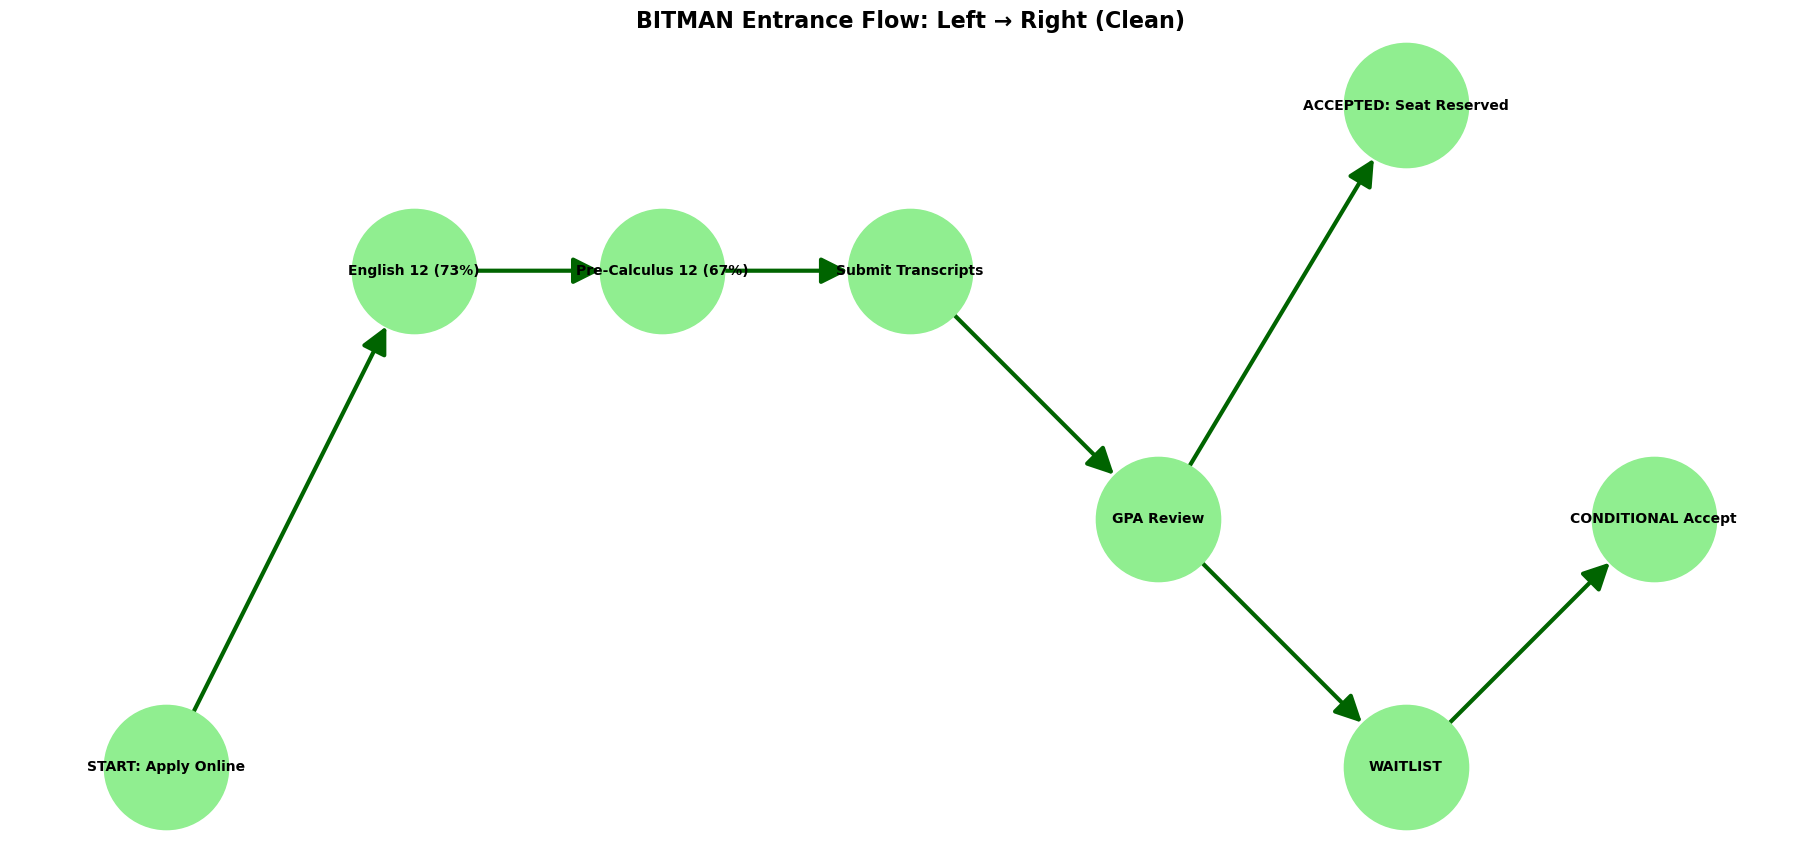

In [6]:
horizontal_pos = {
    'START: Apply Online': (0, 0),
    'English 12 (73%)': (2, 0.6),
    'Pre-Calculus 12 (67%)': (4, 0.6),
    'Submit Transcripts': (6, 0.6),
    'GPA Review': (8, 0.3),
    'ACCEPTED: Seat Reserved': (10, 0.8),
    'WAITLIST': (10, 0),
    'CONDITIONAL Accept': (12, 0.3)
}

plt.figure(figsize=(18, 8))
nx.draw(G, horizontal_pos, 
        with_labels=True,
        node_color='lightgreen',
        node_size=8000,
        font_size=10,
        font_weight='bold',
        arrowsize=40,
        edge_color='darkgreen',
        arrows=True,
        width=3)
plt.title('BITMAN Entrance Flow: Left → Right (Clean)', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('bitman_flow_clean.png', dpi=300, bbox_inches='tight')
plt.show()

## Info Slide
### Slide with project information

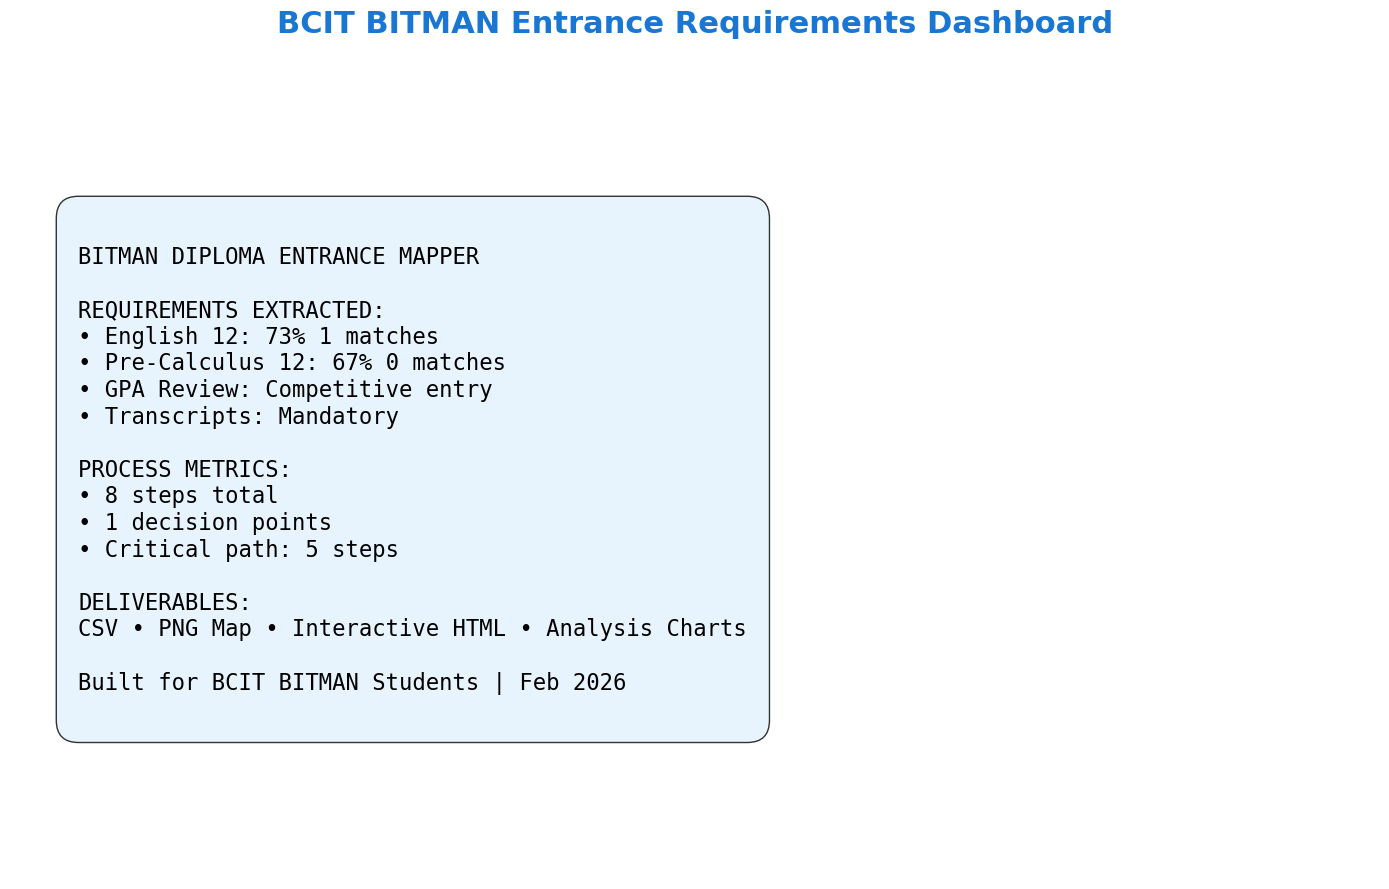

In [8]:
fig, ax = plt.subplots(figsize=(14, 9))
ax.axis('off')

slide_content = f"""
BITMAN DIPLOMA ENTRANCE MAPPER

REQUIREMENTS EXTRACTED:
• English 12: 73% {len(parsed_reqs['English'])} matches
• Pre-Calculus 12: 67% {len(parsed_reqs['Math'])} matches  
• GPA Review: Competitive entry
• Transcripts: Mandatory

PROCESS METRICS:
• {G.number_of_nodes()} steps total
• {sum(G.out_degree(n)>1 for n in G.nodes())} decision points
• Critical path: {len(nx.shortest_path(G, 'START: Apply Online', 'ACCEPTED: Seat Reserved'))-1} steps

DELIVERABLES:
CSV • PNG Map • Interactive HTML • Analysis Charts

Built for BCIT BITMAN Students | Feb 2026
"""

ax.text(0.05, 0.5, slide_content, fontsize=16, va='center', 
        fontfamily='monospace', transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=1", facecolor='#E3F2FD', alpha=0.8))
ax.set_title('BCIT BITMAN Entrance Requirements Dashboard', fontsize=22, 
             fontweight='bold', pad=20, color='#1976D2')

plt.tight_layout()
plt.savefig('BITMAN_Entrance_Summary_Slide.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()